# Results visualisation with `tv.viz`

Two kinds of output:

* **Images and video** (OpenCV, BGR arrays): `FrameAnnotator` draws a
  `FrameResult` onto its frame, `PitchRadar` draws a top-down pitch,
  `overlay` combines them and `render_video` writes the whole clip.
* **Analysis figures** (matplotlib): `plot_heatmap`, `plot_tracks`,
  `plot_distance_histogram`, `draw_pitch` and `show`.

Colours follow the team ids from the pipeline everywhere, so figures match the
video.

Part of the [TactiFoot Vision notebooks](README.md). The pipeline itself is
explained in [04_inference](04_inference.ipynb); here it only produces
something to draw.

In [1]:
import importlib.util
import os
import shutil
import subprocess
import warnings
from pathlib import Path

import numpy as np
from IPython.display import Video
from matplotlib.figure import Figure

import tactifoot_vision as tv

# The repository root, found by walking up from the working directory and kept
# relative, so printed paths do not depend on where the repository lives.
_root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file()
)
ROOT = Path(os.path.relpath(_root))
DATA, MODELS = ROOT / "data", ROOT / "models"
OUT = ROOT / "outputs" / "notebooks" / "05_visualisation"
VIDEO = DATA / "videos" / "broadcast_60s.mp4"

tv.setup_logging("WARNING")
# Most figures are video frames: JPEG keeps the saved notebook small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "pil_kwargs": {"quality": 85}}

video = tv.VideoReader(VIDEO)
detector = tv.load_model("yolo", MODELS / "football_yolo11m.pt", conf=0.3)
pitch_model = tv.load_model("yolo_pose", MODELS / "pitch_yolov8n_pose.pt")
pipeline = tv.Pipeline(
    detector=detector,
    keypoint_model=pitch_model,
    team_classifier=tv.teams.TeamClassifier(embedder="siglip"),
)
result = pipeline.run(VIDEO, end=250, progress=False)
frame_result = result[200]
frame = video.read(frame_result.index)
print(len(result), "frames,", len(result.track_ids), "tracks")

250 frames, 38 tracks


## Annotated frames

`FrameAnnotator` has two styles. `standard` draws boxes; `video_game` draws
ellipses at the players' feet and a triangle over the ball. Both label people
with their track id, colour them by team (referees in the default colour),
draw the confident pitch keypoints and project the pitch lines with the
homography. The demo clip has no goalkeeper or referee track and the ball is
visible in only a few frames, so their styles are described rather than shown.

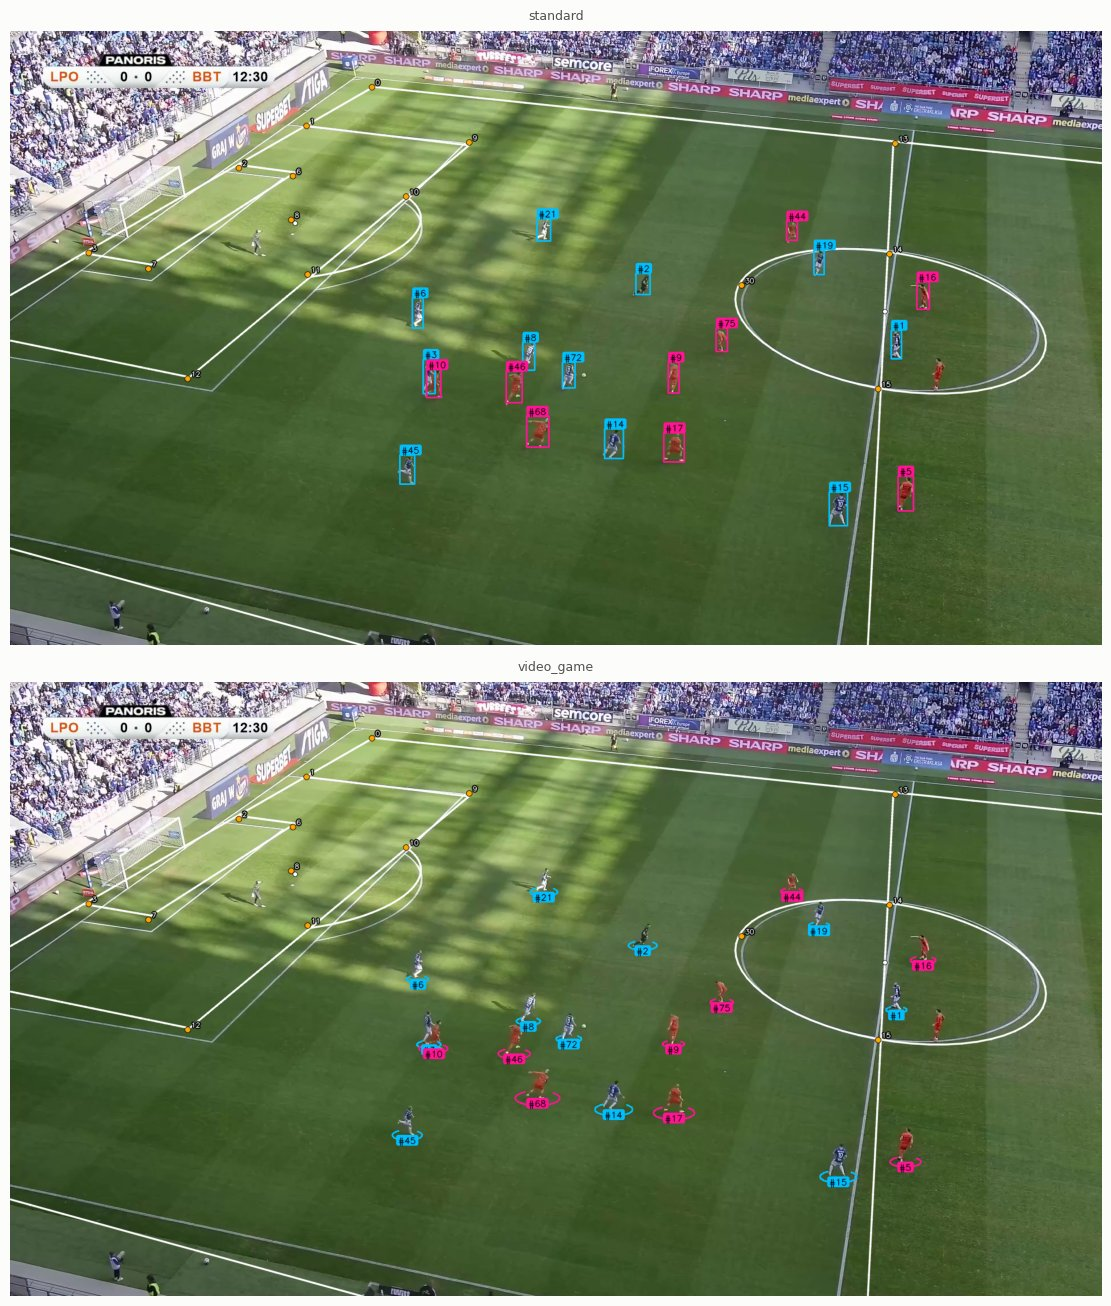

In [2]:
styles = {
    style: tv.viz.FrameAnnotator(style=style).annotate(frame, frame_result)
    for style in ("standard", "video_game")
}
tv.show(list(styles.values()), titles=list(styles), cols=1, width=11)

Every layer has a flag: `draw_boxes`, `draw_labels`, `draw_keypoints`,
`draw_pitch_lines` and `draw_masks`. Turning one off at a time shows what each
adds. Keypoints are orange where the homography agrees with them and red where
it does not, a quick check of the pitch fit.

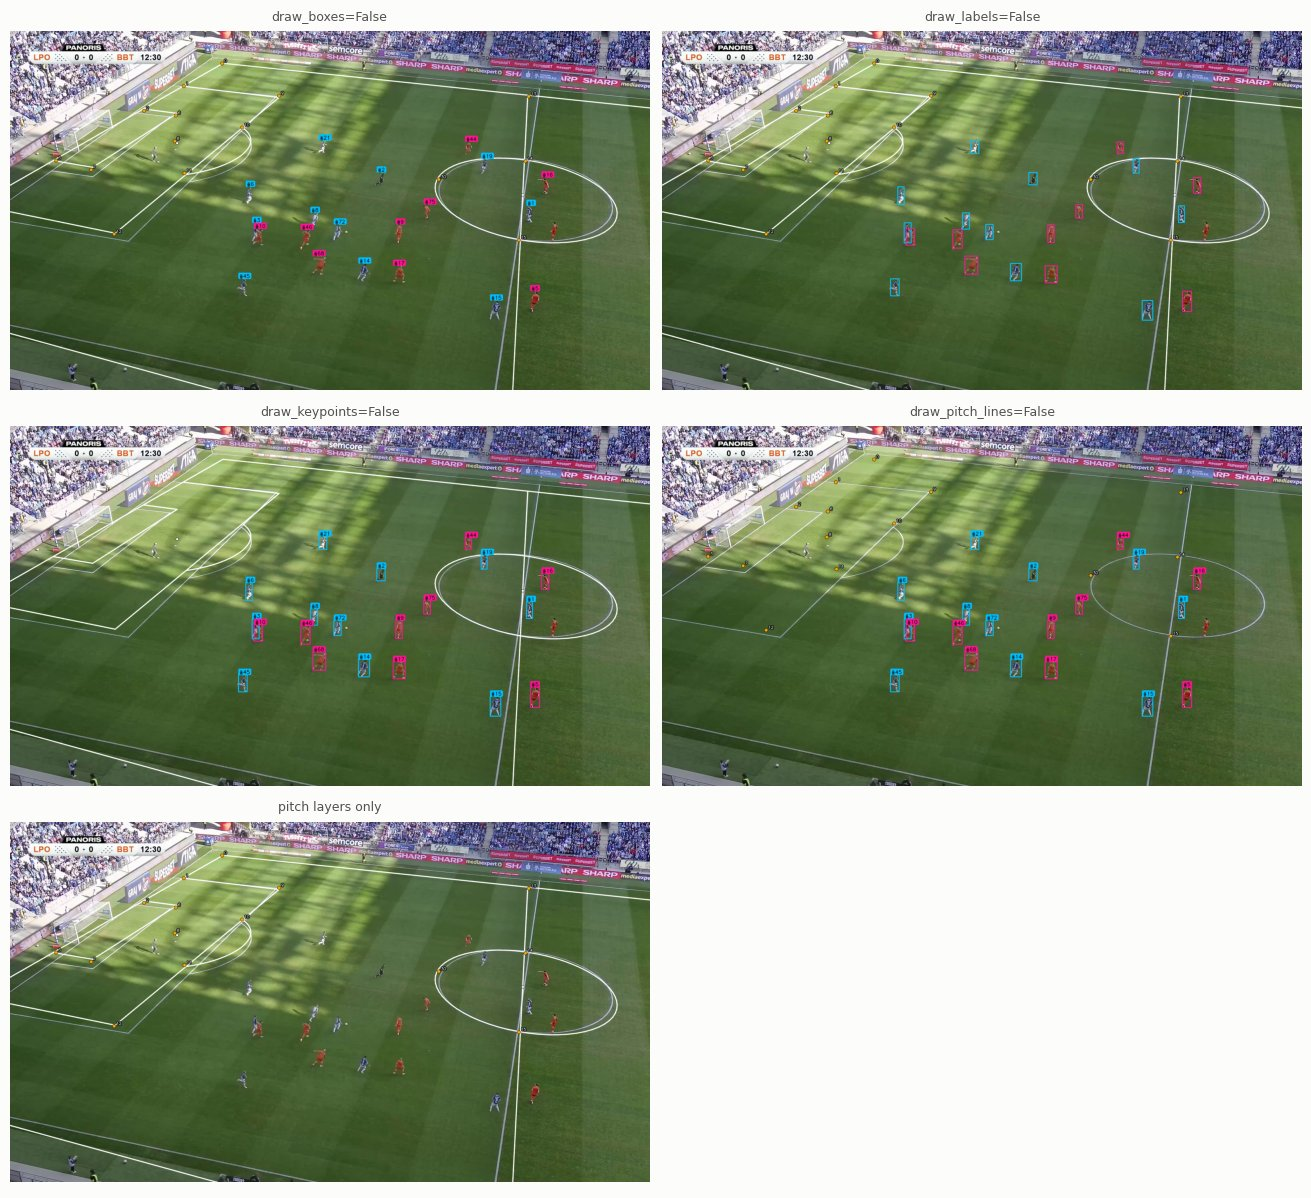

In [3]:
flags = ["draw_boxes", "draw_labels", "draw_keypoints", "draw_pitch_lines"]
views = [
    tv.viz.FrameAnnotator(**{flag: False}).annotate(frame, frame_result)
    for flag in flags
]
only_pitch = tv.viz.FrameAnnotator(draw_boxes=False, draw_labels=False).annotate(
    frame, frame_result
)
tv.show(
    [*views, only_pitch],
    titles=[f"{flag}=False" for flag in flags] + ["pitch layers only"],
    cols=2,
    width=13,
)

Colours and thresholds are arguments too: `team_colors`, `default_color`,
`ball_color`, `pitch_line_color` and `keypoint_threshold`.

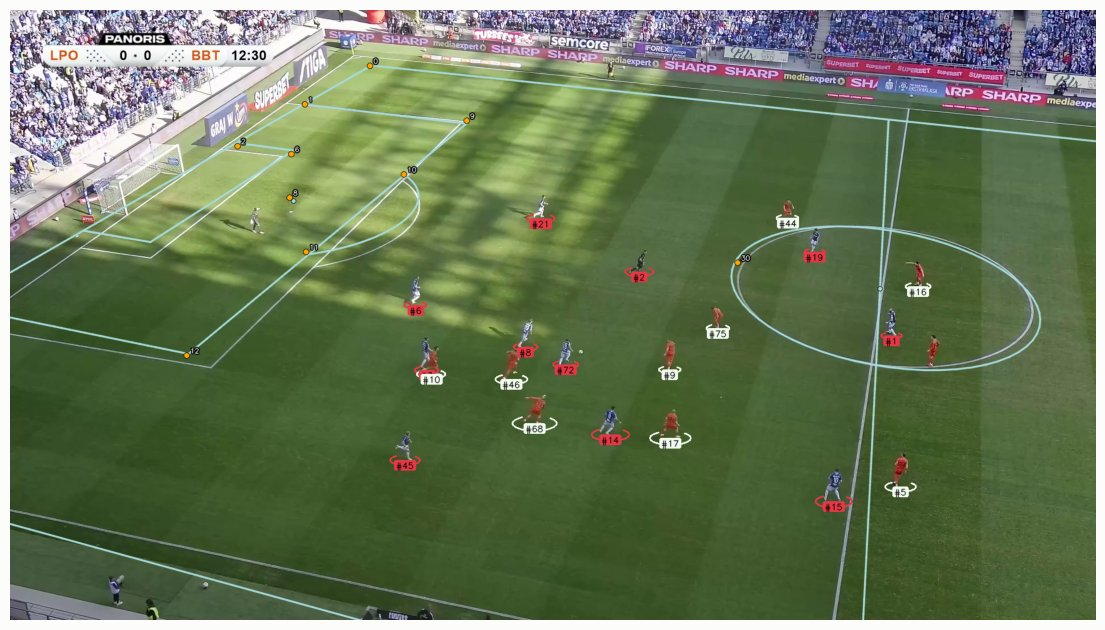

In [4]:
custom = tv.viz.FrameAnnotator(
    style="video_game",
    team_colors=["#E63946", "#F1FAEE"],
    default_color="#222222",
    ball_color="#FFD400",
    pitch_line_color="#A8DADC",
    keypoint_threshold=0.8,
)
tv.show(custom.annotate(frame, frame_result), width=11)

`draw_masks=True` draws segmentation masks, which only a mask tracker (SAM2)
produces and only `Pipeline(keep_masks=True)` keeps. With a box tracker there
are no masks; the annotator then warns once and draws the rest.

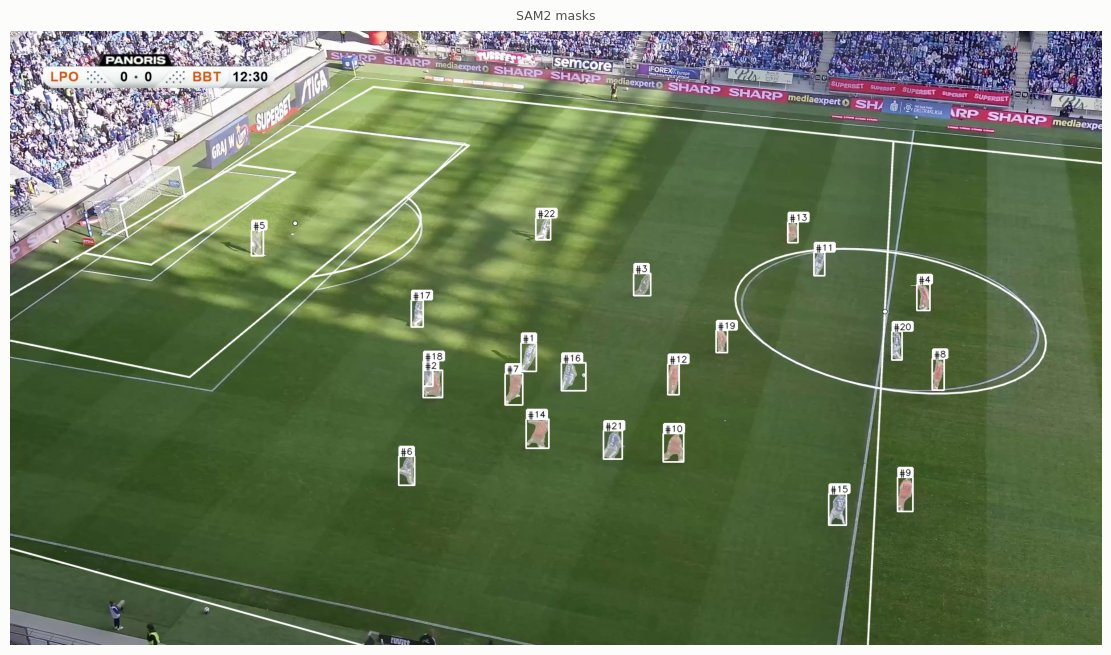

In [5]:
SAM2_REPO = ROOT / "external" / "segment-anything-2-real-time"
if SAM2_REPO.is_dir() and importlib.util.find_spec("hydra") is not None:
    warnings.filterwarnings(
        "ignore", message="Falling back to the Python connected-components"
    )
    sam2 = tv.tracking.create_tracker(
        "sam2",
        checkpoint=SAM2_REPO / "checkpoints" / "sam2.1_hiera_tiny.pt",
        config=SAM2_REPO / "sam2" / "configs" / "sam2.1" / "sam2.1_hiera_t.yaml",
    )
    masked = tv.Pipeline(
        detector=detector, keypoint_model=pitch_model, tracker=sam2, keep_masks=True
    ).run(
        VIDEO, start=frame_result.index - 30, end=frame_result.index + 1, progress=False
    )
    masks_view = tv.viz.FrameAnnotator(draw_masks=True, draw_keypoints=False).annotate(
        frame, masked[-1]
    )
    display(tv.show(masks_view, titles="SAM2 masks", width=11))
else:
    print(
        "SAM2 is not available (see 04_inference); without masks draw_masks only warns:"
    )
    display(
        tv.show(
            tv.viz.FrameAnnotator(draw_masks=True).annotate(frame, frame_result),
            width=11,
        )
    )

## Pitch radar and overlay

`PitchRadar` draws a frame's pitch positions top-down, coloured like the video.
`draw_ids` writes track ids into the dots; size, colours and line widths are
arguments.

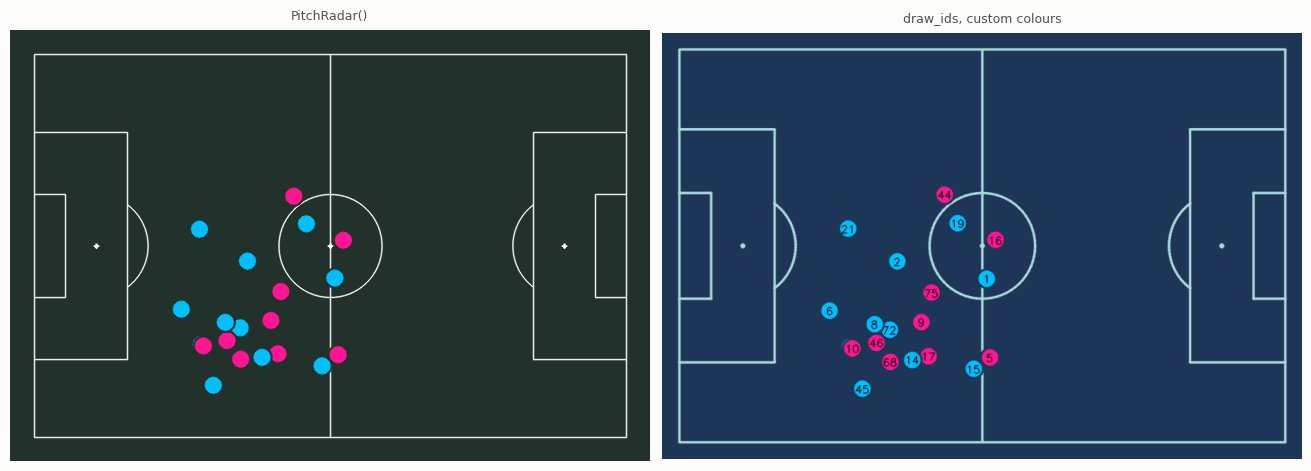

In [6]:
radar = tv.viz.PitchRadar()
radar_ids = tv.viz.PitchRadar(
    draw_ids=True, width_px=900, pitch_color="#1D3557", line_color="#A8DADC"
)
tv.show(
    [radar.draw(frame_result), radar_ids.draw(frame_result)],
    titles=["PitchRadar()", "draw_ids, custom colours"],
    cols=2,
    width=13,
)

`draw_points` puts arbitrary pitch positions on the radar. With
`SoccerPitch(120, 80)` it draws a StatsBomb freeze frame in StatsBomb units.

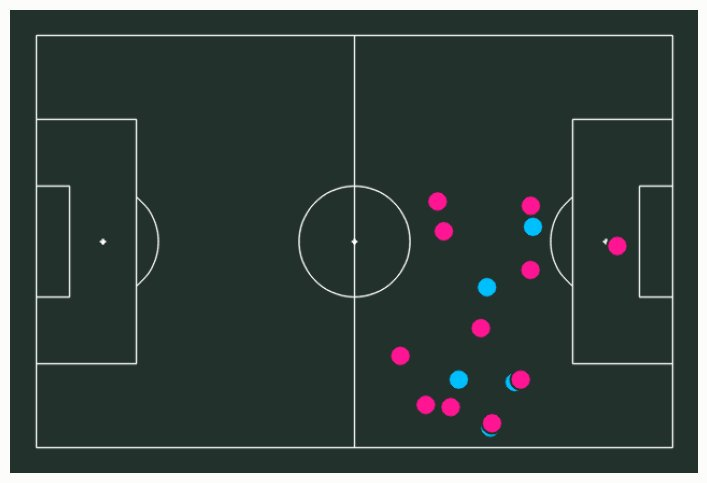

In [7]:
statsbomb = tv.data.load_statsbomb(DATA / "statsbomb")
event = statsbomb[statsbomb["event_uuid"] == statsbomb["event_uuid"].iloc[0]]
statsbomb_radar = tv.viz.PitchRadar(pitch=tv.SoccerPitch(120, 80))
colors = np.where(event["teammate"], "#00BFFF", "#FF1493").tolist()
tv.show(
    statsbomb_radar.draw_points(np.array(event["pitch_location"].tolist()), colors),
    width=7,
)

`overlay` pastes the radar onto the frame: `position` picks the corner,
`width_fraction` the size and `alpha` the opacity.

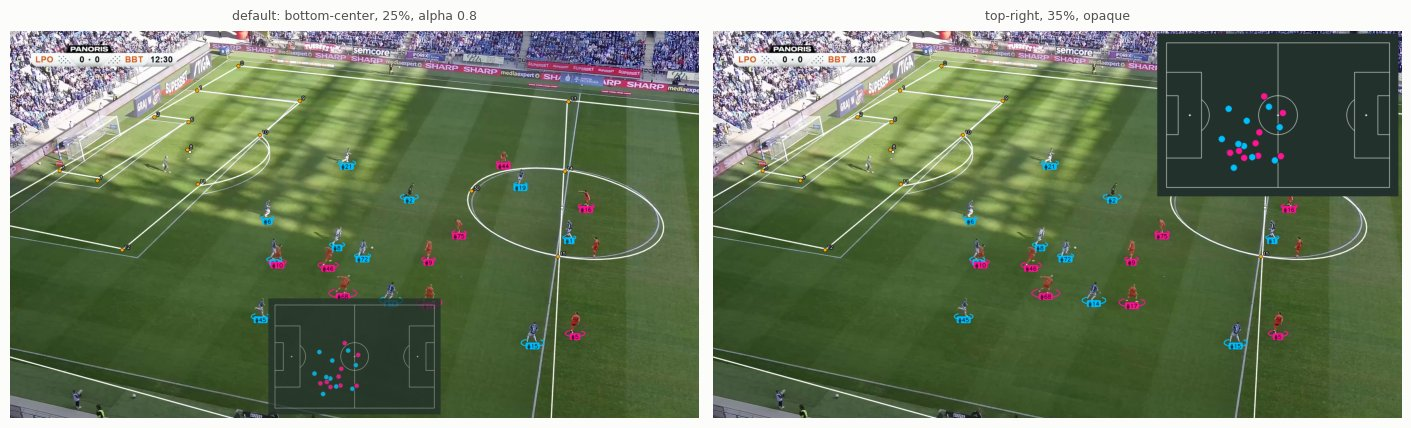

In [8]:
annotated = styles["video_game"]
image = radar.draw(frame_result)
tv.show(
    [
        tv.viz.overlay(annotated, image),
        tv.viz.overlay(
            annotated, image, position="top-right", width_fraction=0.35, alpha=1.0
        ),
    ],
    titles=["default: bottom-center, 25%, alpha 0.8", "top-right, 35%, opaque"],
    cols=2,
    width=14,
)

## Rendering a video

`render_video` re-reads the source video and writes every processed frame,
annotated and with the radar overlay, to an mp4. It checks that the video and
the result match (frame size, fps) and that the radar uses the result's pitch.
Pass your own annotator and radar, or `radar=False` for none.

VideoReader('../outputs/notebooks/05_visualisation/annotated.mp4', 1920x1080, 25.00 fps, 250 frames)


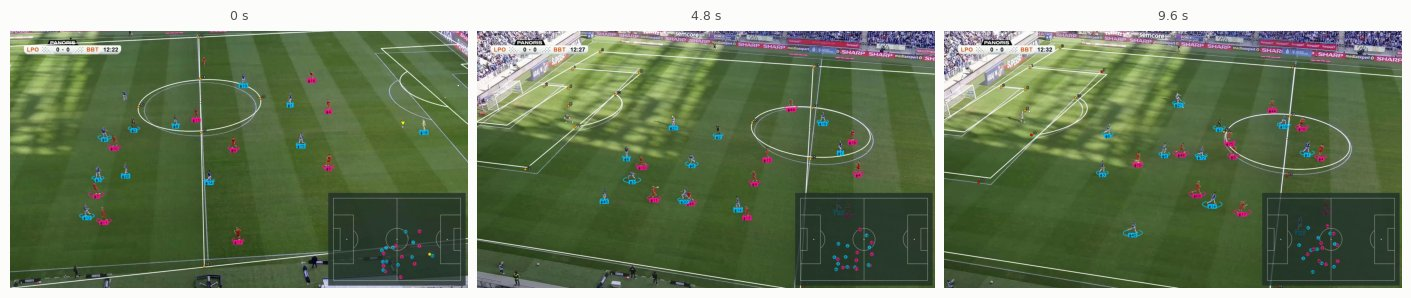

In [9]:
video_path = tv.viz.render_video(
    result,
    VIDEO,
    OUT / "annotated.mp4",
    annotator=tv.viz.FrameAnnotator(style="video_game"),
    radar=tv.viz.PitchRadar(draw_ids=True),
    overlay_position="bottom-right",
    overlay_width_fraction=0.3,
    progress=False,
)
rendered = tv.VideoReader(video_path)
print(rendered)
tv.show(
    [rendered.read(i) for i in (0, 120, 240)],
    titles=["0 s", "4.8 s", "9.6 s"],
    cols=3,
    width=14,
)

OpenCV writes MPEG-4 Part 2, which browsers do not play. With `ffmpeg`
installed the next cell re-encodes a small H.264 copy and links it below
(the video file stays in `outputs/`, it is not stored in the notebook).

In [10]:
if shutil.which("ffmpeg"):
    web_video = video_path.with_name("annotated_h264.mp4")
    subprocess.run(
        [
            "ffmpeg",
            "-y",
            "-loglevel",
            "error",
            "-i",
            str(video_path),
            "-vf",
            "scale=960:-2",
            "-c:v",
            "libx264",
            "-pix_fmt",
            "yuv420p",
            str(web_video),
        ],
        check=True,
    )
    display(Video(str(web_video), width=960))
else:
    print("ffmpeg not found; open", video_path, "in a video player")

## Analysis plots

`plot_heatmap` shows where players spent time, for everybody or one team in
its team colour. Like the other plotting helpers it draws into a given `ax`,
so several fit in one figure.

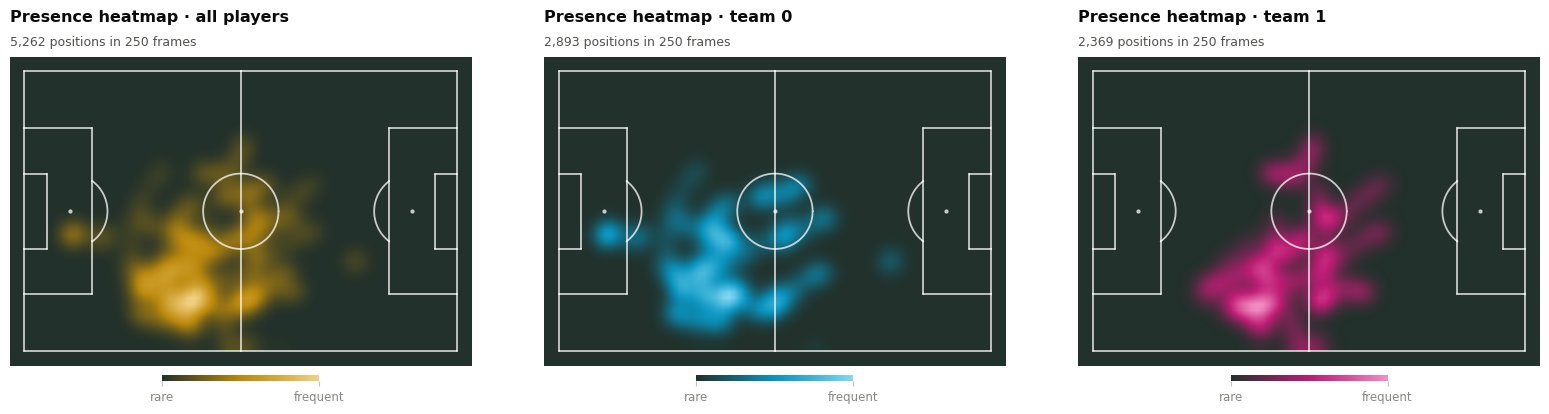

In [11]:
fig = Figure(figsize=(16, 4), layout="constrained")
for ax, team in zip(fig.subplots(1, 3), (None, 0, 1), strict=True):
    tv.viz.plot_heatmap(result, team=team, ax=ax)
fig

`plot_tracks` draws trajectories on the pitch, by default of the tracks with
the most positions; `track_ids` picks specific ones.

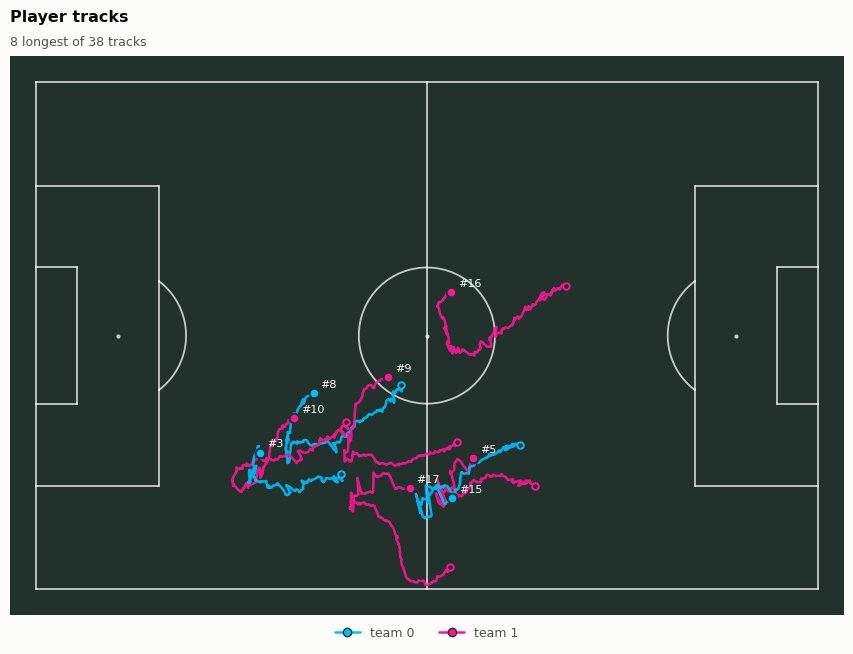

In [12]:
tv.viz.plot_tracks(result, max_tracks=8)

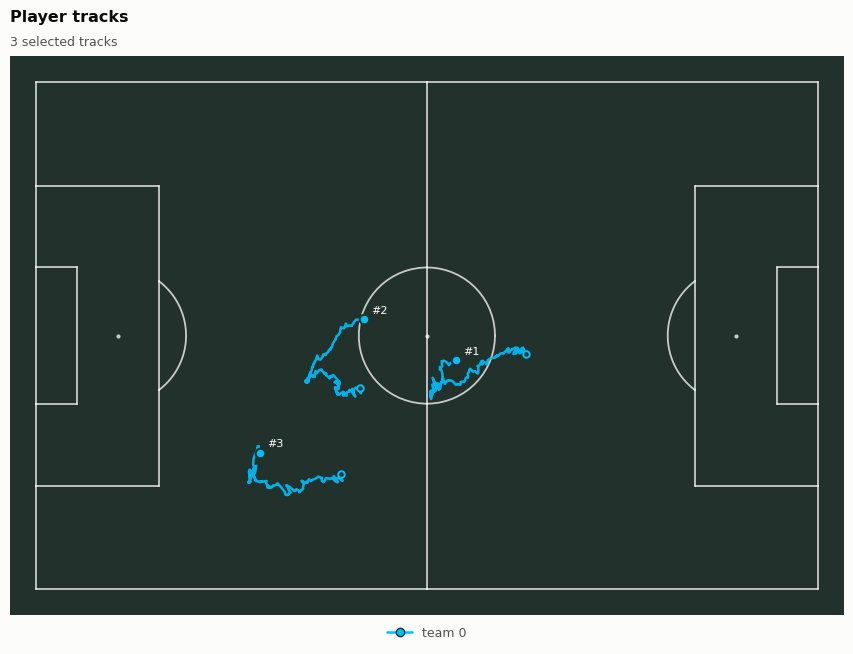

In [13]:
tv.viz.plot_tracks(result, track_ids=result.track_ids[:3])

`plot_distance_histogram` plots any set of distances with the median marked.
It is made for `compare_with_statsbomb` errors (see
[04_inference](04_inference.ipynb)); here it shows how far each track moved
during the clip. Frame-to-frame jitter of the homography adds to these
distances, so they overestimate what the players really ran.

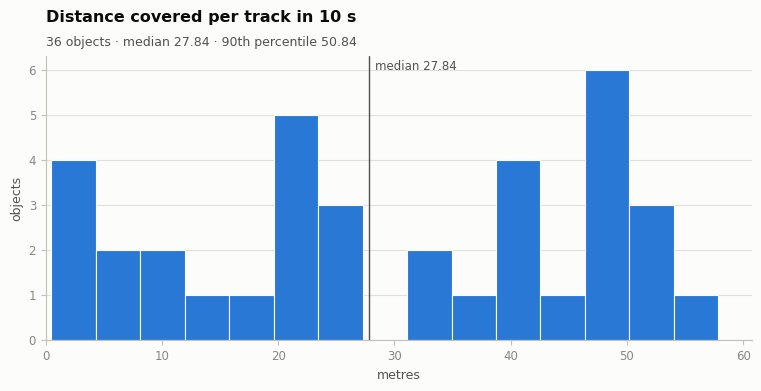

In [14]:
tracks = result.to_dataframe()
people = tracks[(tracks["object"] == "person") & tracks["pitch_x"].notna()].sort_values(
    "frame"
)
steps = people.groupby("track_id")[["pitch_x", "pitch_y"]].diff()
covered = np.hypot(steps["pitch_x"], steps["pitch_y"]).groupby(people["track_id"]).sum()
tv.viz.plot_distance_histogram(
    covered[covered > 0],
    bins=15,
    title="Distance covered per track in 10 s",
    xlabel="metres",
)

`draw_pitch` gives an empty pitch to plot anything on, in pitch units with `y`
pointing down like the radar. Here: every player position of the clip.

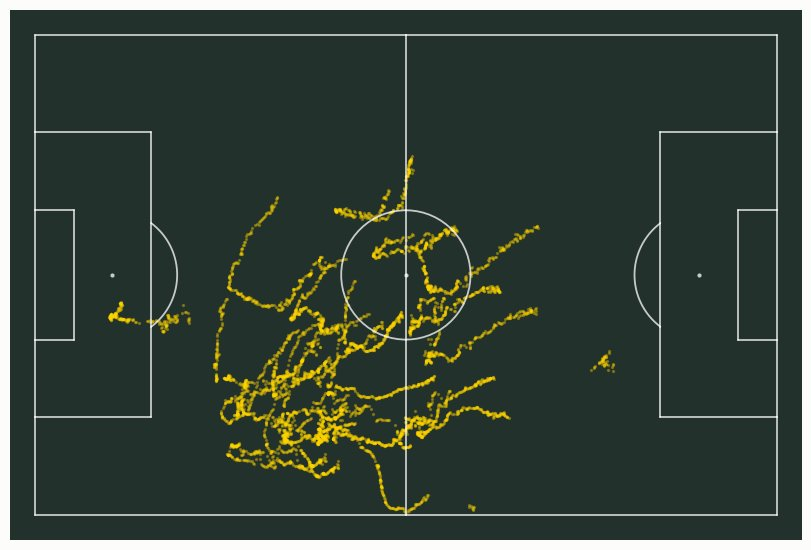

In [15]:
fig = tv.viz.draw_pitch(pitch=result.pitch, size=8)
fig.axes[0].scatter(
    people["pitch_x"], people["pitch_y"], s=2, alpha=0.3, color="#FFD400"
)
fig

`show` is the image grid used throughout these notebooks: one image or a list,
optional titles, `cols` per row and `width` in inches. Images are BGR by
default (pass `bgr=False` for RGB arrays); 2-D arrays show in grayscale.

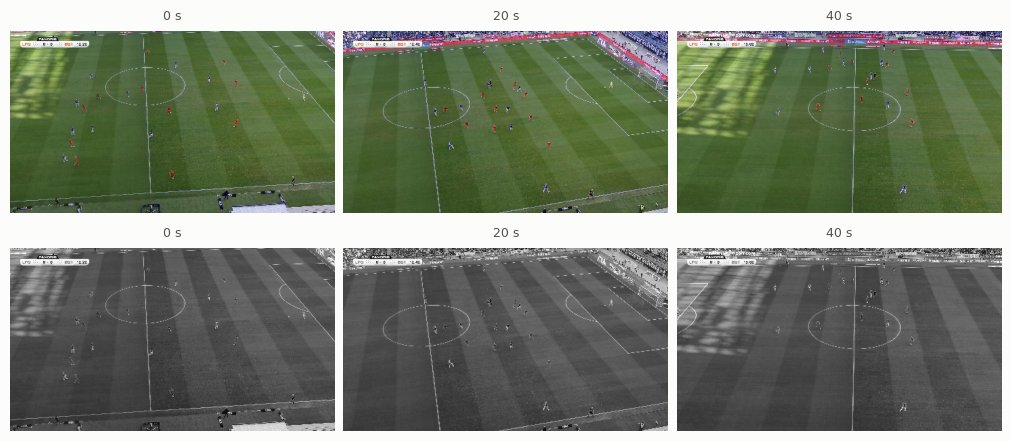

In [16]:
small = [video.read(i)[::4, ::4] for i in (0, 500, 1000)]
gray = [img.mean(axis=2).astype(np.uint8) for img in small]
tv.show(small + gray, titles=["0 s", "20 s", "40 s"] * 2, cols=3, width=10)